# Monte Carlo Learning implementation on Frozen Lake environment

This project implements **Monte Carlo learning algorithm** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

In [3]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

## Testing the environment

In [4]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

lake_grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [5]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [6]:
# let's test the move method, if we are at (0, 0) state and try to move up, we should be at the same state
current_state = State((0, 0), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]
result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state ? : ", result["is_terminated"])

prev state:  (0, 0)
next state:  (0, 0)
reward:  0.0
is terminal state ? :  False


In [7]:
# Now let's test the transition prob, if we are at the Goal "G" i.e (2, 2) and try to move, we are supposed to stuck to that state
current_state = State((2, 2), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]

result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state? :", result["is_terminated"])

prev state:  (2, 2)
next state:  (2, 2)
reward:  0
is terminal state? : True


In [8]:
# Now let's test the transition prob for near goal state

current_state = State((1, 2), frozen_lake.n_cols)
action_index = frozen_lake.action_to_idx["up"]

result = frozen_lake.step(current_state, action_index)

print("prev state: ", current_state.coord)
print("next state: ", result["new_state"].coord)
print("reward: ", result["reward"])
print("is terminal state? :", result["is_terminated"])

prev state:  (1, 2)
next state:  (1, 2)
reward:  0.0
is terminal state? : False


# Monte Carlo Learning

Monte Carlo (MC) learning is a class of model-free reinforcement learning methods that learn value functions from complete episodes of experience, using sampled returns instead of a model of the environment.

**Unlike Dynamic Programming:**
- ❌ No transition model 𝑃(𝑠′∣𝑠,𝑎)
- ❌ No reward model 𝑅(𝑠,𝑎)
- ✅ Learns directly from experience

## The simplest Monte-carlo-based RL algorithm 
- The key to understand the algorithm is to understand <span style="color:green"> how to convert the policy iteration algorithm to be model free </span>
- Policy iteration has two steps in each iteration:
    - policy evaluation:
        - For a given policy ${\pi_k}$, we calculate state value ${v_{\pi_k}}$ by solving the Bellman's equation ${v_{\pi_k} = r_{\pi_k} + \gamma P_{\pi_k} v_{\pi_k} }$
    - policy improvement:
        - once ${v_{\pi_k}}$ is know, we improve the policy ${\pi_{k+1} = argmax_{\pi} (r_\pi + \gamma P_\pi v_{\pi_k})}$

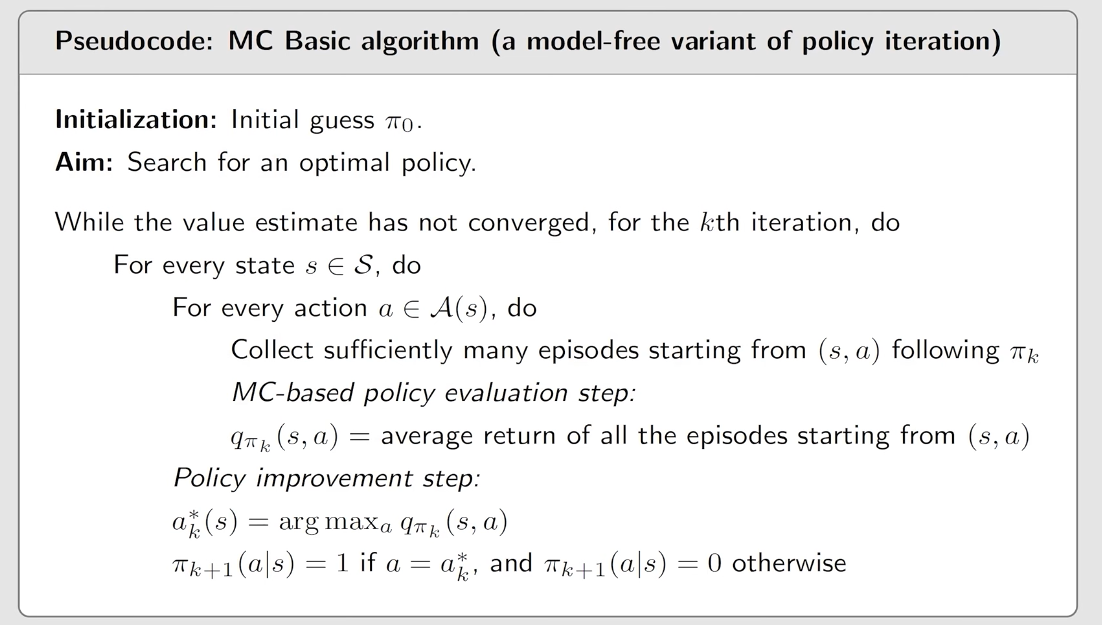

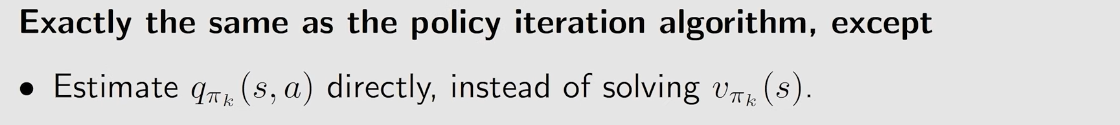

# Keypoints:
- MC basic is a variant of policy iteration algorithm
- The model-free algorithm are build up based on model-based one
- MC basic is useful to reveal the core idea of Monte-Carlo-based model-free RL, but not practical due to low efficiency.
- Why does MC basic estimates action values instead of state values?
  - because state values cannot be used to improve policies directly. When models are not available we should directly estimate action values.
- Since policy iteration is convergent, the convergence of MC basic is also guaranteed, given sufficient episodes. 

## Data structure of Policy and Q value (action-state value)
For this implementation, we will represent the policy as a 1D array, where the index corresponds to the 1D state index and the value represents the action index.

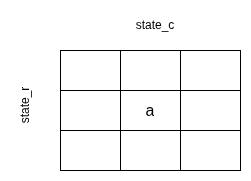


On the other hand, we will represent the Q-value table as a 2D matrix, where each row corresponds to the 1D state index, each column corresponds to the action index, and each value represents the Q-value for that state–action pair.

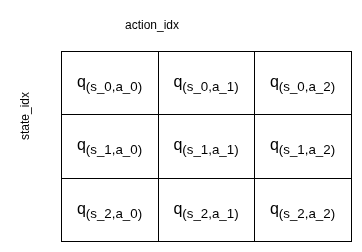


In [9]:
def run_episode(env, policy, state, action_idx, gamma=0.99, max_steps=1000, episode_num=0, verbose=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    total_reward = 0
    for step in range(max_steps):        
        out = env.step(state, action_idx)
        next_state = out["new_state"]
        reward = out["reward"]
        is_terminated = out["is_terminated"]
        
        total_reward += gamma**step * reward

        prev_state = state
        state = next_state
        action_idx = policy[state.idx]

        
        if verbose == 1:
            print(f"step {step}: current_state: {prev_state.coord} -> Action: {env.action_idx_to_name[action_idx]}{action_idx} -> Reward: {reward} -> Next state: {next_state.coord}")
        elif verbose == 2:
            env.render(policy, current_state, episode_num, step, total_reward)
            
        if is_terminated:
            break  
            
    return total_reward

In [10]:
frozen_lake.grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [11]:
policy = np.zeros(frozen_lake.n_states)
print("Initial policy: ", policy)

Initial policy:  [0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
current_state = State((0, 0), frozen_lake.n_cols)

run_episode(env=frozen_lake,
            policy=policy,
            state=current_state,
            action_idx=2,
            episode_num=0,
            verbose=2)

,0,1,2
0,🤖,❄️ ←,❄️ ←
1,❄️ ←,🕳️,❄️ ←
2,❄️ ←,❄️ ←,🏁


0.0

In [13]:
def policy_evaluation(env, policy, Q, num_episode=100, max_steps=1000):
    for s in range(env.n_states):
        for a in env.all_action_idx:
            current_state = State(s, env.n_cols)
            total_G = 0
            for e in range(num_episode):
                total_G += run_episode(env,
                                       policy,
                                       current_state,
                                       a,
                                       episode_num=e,
                                       max_steps=max_steps,
                                       verbose=0)

            avg_G = total_G / num_episode
            Q[current_state.idx][a] = avg_G
    return Q

In [14]:
def policy_improvement(env, Q, gamma=0.99):
    new_policy = np.zeros(env.n_states, dtype=np.int8)
    for s in range(env.n_states):
        state = State(s, env.n_cols)
        r, c  = state.coord
        
        if env.grid[r][c] in env.terminal_states:
            continue
            
        action_values = []
        for action in env.all_action_idx:                
            q = Q[state.idx][action]
            action_values.append(q)
            
        # pick a greedy action with a highest action value
        new_policy[state.idx] = np.argmax(action_values).item()
    return new_policy

In [15]:
def mc_basic_run(env, num_episode=1000, max_steps=1000):
    policy_history = []
    Q_history = []
    n_rows = env.n_rows
    n_cols = env.n_cols
    policy = np.zeros(env.n_states, dtype=np.int8)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)
    while True:
        Q = policy_evaluation(env, policy,
                              Q, num_episode, max_steps)
        new_policy = policy_improvement(env, Q)
        
        if np.array_equal(policy, new_policy):
            break
    
        policy = new_policy
        policy_history.append(policy)
        Q_history.append(Q)
        
    return policy, Q, policy_history, Q_history

In [16]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points = reward_points,
                                    slippery=True)

In [17]:
policy, Q, policy_history, Q_history = mc_basic_run(frozen_lake, num_episode=100, max_steps=100)

In [18]:
policy

array([2, 2, 1, 1, 0, 1, 2, 2, 0], dtype=int8)

In [19]:
Q

array([[6.160173 , 7.2518663, 7.5447526, 6.833157 ],
       [5.986356 , 2.9756186, 7.3074937, 6.332202 ],
       [7.2390757, 8.403469 , 8.083692 , 8.226704 ],
       [6.4027967, 7.7343936, 2.0136123, 6.162944 ],
       [0.       , 0.       , 0.       , 0.       ],
       [3.0413115, 8.172228 , 7.9831266, 7.0589495],
       [7.781705 , 8.558232 , 8.737654 , 6.953461 ],
       [7.690391 , 8.080213 , 8.845437 , 2.362689 ],
       [0.       , 0.       , 0.       , 0.       ]], dtype=float32)

let's convert policy into 2D

In [20]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [23]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 1],
       [1, 0, 1],
       [2, 2, 0]], dtype=int16)

# Render policy

In [24]:
import pandas as pd
from IPython.display import display

In [25]:
render_policy_and_value(frozen_lake, policy)

Policy:


,0,1,2
0,→,→,↓
1,↓,🕳️,↓
2,→,→,🏁


# Animate policy and state value history

In [42]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [43]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [51]:
grid = generate_grid_randomly(5, 5, n_holes=3)
grid

[['F', 'F', 'F', 'F', 'F'],
 ['H', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'G', 'F'],
 ['F', 'F', 'F', 'F', 'F'],
 ['F', 'H', 'F', 'H', 'S']]

In [52]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

policy, Q, policy_history, V_history = mc_basic_run(frozen_lake)

In [53]:
len(policy_history)

12

In [54]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())